In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent, GreedyAgent
from ant.decentralised.special_strategies import EgalitarianAgent, PettyAgent, ImitationAgent, SatisficingAgent
from ant.centralised import P4

In [2]:
market_size = 20
simulation_length = 400
num_repeats = 30

graph_types = ["complete", "random", "grid", "scale-free", "Small-World"]

strategies = {
    "Proportional": ProportionalAgent,
    "Greedy": GreedyAgent,
    "Egalitarian": EgalitarianAgent,
    "Petty": PettyAgent,
    "Imitation": ImitationAgent,
    "Satisficing": SatisficingAgent
}

all_results = {strategy: {gtype: [] for gtype in graph_types} for strategy in strategies}

In [3]:
for repeat in range(num_repeats):
    print(f"Running repeat {repeat + 1}/{num_repeats}...")

    current_seed = 657849724 + repeat
    
    rnd_seed = current_seed
    random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    while not nx.is_connected(random_graph):
        rnd_seed += 1000  
        random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    
    graphs = {
        "complete": nx.complete_graph(market_size),
        "random": random_graph,
        "grid" : nx.convert_node_labels_to_integers(nx.grid_2d_graph(int(market_size / 4), 4)),
        "scale-free" : nx.barabasi_albert_graph(market_size, 1, seed=current_seed),
        "Small-World": nx.connected_watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=current_seed),
    }

    for graph_type, graph in graphs.items():
        for strategy_name, strategy_cls in strategies.items():
            _market = Market(market_size, graph=graph, seed=current_seed, agent_type=strategy_cls)
            optimal_aloc, utility_vec = P4(_market)
            _market.set_market_equilibrium(optimal_aloc, utility_vec)
            
            simulated_state = _market.simulate(simulation_length)
            all_results[strategy_name][graph_type].append(simulated_state)

Running repeat 1/30...
Running repeat 2/30...
Running repeat 3/30...
Running repeat 4/30...
Running repeat 5/30...
Running repeat 6/30...
Running repeat 7/30...
Running repeat 8/30...
Running repeat 9/30...
Running repeat 10/30...
Running repeat 11/30...
Running repeat 12/30...
Running repeat 13/30...
Running repeat 14/30...
Running repeat 15/30...
Running repeat 16/30...
Running repeat 17/30...
Running repeat 18/30...
Running repeat 19/30...
Running repeat 20/30...
Running repeat 21/30...
Running repeat 22/30...
Running repeat 23/30...
Running repeat 24/30...
Running repeat 25/30...
Running repeat 26/30...
Running repeat 27/30...
Running repeat 28/30...
Running repeat 29/30...
Running repeat 30/30...


In [17]:
training_period = 0
time_steps = np.arange(training_period, simulation_length)

FULL_WIDTH = 3.5
HALF_WIDTH = 1.6

PALETTE = [
    "#66c2a5",
    "#fc8d62",
    "#8da0cb",
    "#e78ac3",
    "#a6d854",
    "#ffd92f",
    "#e5c494",
    "#b3b3b3",

]

MARKERS = ["o", "D", "^", "s", "v", "x"]

DASHES = [
    (),          # solid
    (5, 2),      # dashed
    (2, 2),      # dotted
    (7, 2, 2, 2), # dash-dot
    (5, 2, 2, 2, 2, 2),  # dash-dot-dot
    (1, 1),      # dense dot
]

sns.set_theme(
    style="white",
    palette=PALETTE,
    rc = {
    # Figure
    "figure.figsize":        (5.5, 3.5),
    "figure.dpi":            150,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
    "savefig.pad_inches":    0.05,
    "figure.facecolor":      "white",
    "axes.facecolor":        "white",
 
    # Font — use a serif family for body text similarity; switch to
    # "sans-serif" if your paper uses a sans body font (e.g. ACM 2023).
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif", "Palatino"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":       8,
    "legend.title_fontsize": 7,
 
    # Axes
    "axes.linewidth":        0.6,
    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.prop_cycle":       plt.cycler(color=PALETTE),
 
    # Grid — subtle horizontal lines only
    "axes.grid":             True,
    "axes.grid.axis":        "y",
    "grid.color":            "#cccccc",
    "grid.linewidth":        0.4,
    "grid.linestyle":        "--",
 
    # Ticks
    "xtick.direction":       "out",
    "ytick.direction":       "out",
    "xtick.major.width":     0.6,
    "ytick.major.width":     0.6,
    "xtick.major.size":      3.0,
    "ytick.major.size":      3.0,
    "xtick.minor.visible":   False,
    "ytick.minor.visible":   False,
 
    # Lines & markers
    "lines.linewidth":       1.4,
    "lines.markersize":      5,
    "lines.markeredgewidth": 0.8,
 
    # Legend
    "legend.frameon":        True,
    "legend.framealpha":     0.9,
    "legend.edgecolor":      "#cccccc",
    "legend.borderpad":      0.4,
    "legend.labelspacing":   0.3,
    "legend.handlelength":   2.0,
 
    # Error bars
    "errorbar.capsize":      3,
 
    # PDF/SVG vector output — embed fonts for camera-ready submissions
    "pdf.fonttype":          42,   # TrueType (not Type 3)
    "ps.fonttype":           42,
    "svg.fonttype":          "none",
}

)


# plt.figure(figsize=(FULL_WIDTH, 2.4))
# colors = sns.color_palette("tab10", n_colors=len(strategies))

# for idx, strategy_name in enumerate(strategies.keys()):
#     # collect all repeats across all topologies for this strategy
#     all_repeats = []
#     for g in graph_types:
#         arr = np.array(all_results[strategy_name][g])
#         if arr.size == 0:
#             continue
#         all_repeats.append(arr)     # shape: (n_repeats, timesteps)
#     if len(all_repeats) == 0:
#         continue
#     concatenated = np.concatenate(all_repeats, axis=0)  # (total_repeats, timesteps)
#     mean = np.mean(concatenated, axis=0)
#     std = np.std(concatenated, axis=0)

#     t = np.arange(len(mean))
#     t_plot = t[training_period:]

#     color = colors[idx % len(colors)]
#     plt.plot(t_plot, mean[training_period:], label=f"{strategy_name}", color=color, alpha=1.0)
#     # plt.fill_between(t_plot, (mean - std)[training_period:], (mean + std)[training_period:],
#     #                  color=color, alpha=0.15)

#     # add sparse markers for print readability
#     # marker_step = max(1, len(t_plot) // 25)
#     # plt.plot(t_plot[::marker_step], mean[training_period:][::marker_step], marker='o',
#     #          linestyle='None', color=color, markersize=5, alpha=0.9)

# plt.xlabel("Time Steps")
# plt.ylabel("Loss")
# # plt.title(f"Comparing Strategies Averaged Over {num_repeats} Repeats & All Topologies")
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
# plt.grid(True, alpha=0.25)
# plt.tight_layout()
# plt.savefig("figs/pure/aggregate.pdf", dpi=500, bbox_inches="tight")
# plt.show()

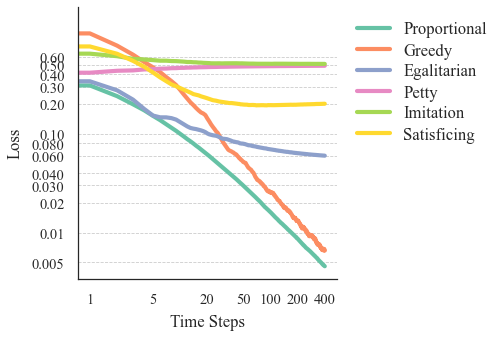

In [23]:
import matplotlib.ticker as ticker
rows = []
for strategy_name in strategies:
    for graph_type in graph_types:
        for repeat_id, series in enumerate(all_results[strategy_name][graph_type]):
            series = np.asarray(series)
            for t in range(training_period, len(series)):
                rows.append(
                    {
                        "strategy": strategy_name,
                        "graph_type": graph_type,
                        "repeat": repeat_id,
                        "timestep": t,
                        "loss": series[t],
                    }
                )

df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(FULL_WIDTH, 2.4))
sns.lineplot(
    data=df,
    x="timestep",
    y="loss",
    hue="strategy",
    estimator="mean",
    errorbar=None,
    linewidth=2,
)
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_yticks([0.60,0.50,0.40, 0.30,0.20,0.10,0.03, 0.04, 0.06, 0.08, 0.02, 0.01, 0.005])
ax.set_yticklabels(["0.60","0.50","0.40", "0.30","0.20","0.10","0.030", "0.040", "0.060", "0.080", "0.02", "0.01", "0.005"])

ax.set_xticks([1, 5, 20, 50, 100, 200, 400])
ax.set_xticklabels(["1", "5", "20", "50", "100", "200", "400"])


# ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
# ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.xlabel("Time Steps")
plt.ylabel("Loss")
plt.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.savefig("figs/pure/aggregate.pdf")
plt.show()

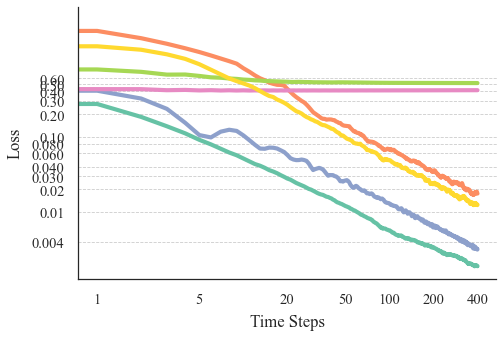

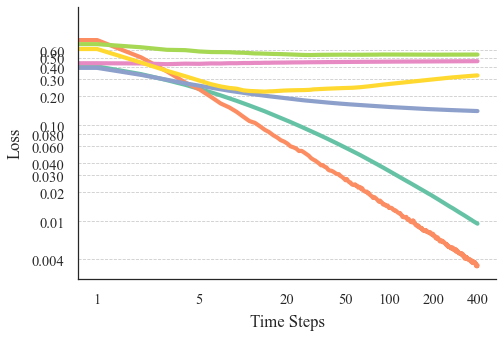

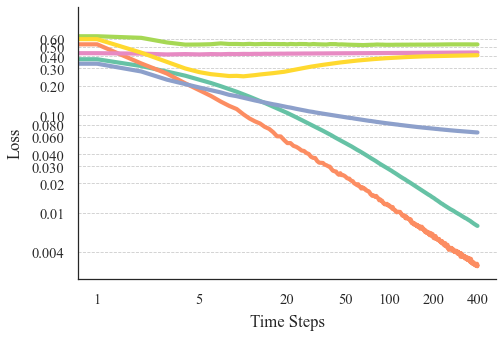

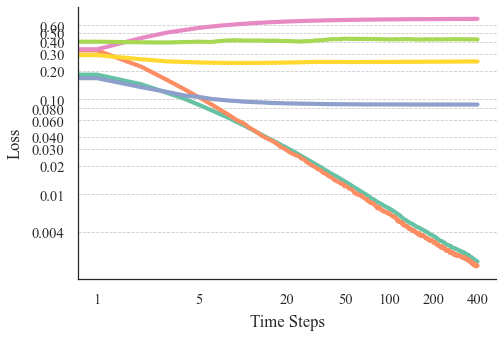

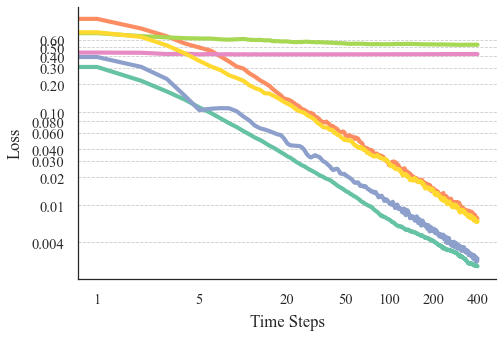

In [24]:
for graph_type in graph_types:
    fig, ax = plt.subplots(figsize=(FULL_WIDTH, 2.4))
    subset = df[df["graph_type"] == graph_type]

    sns.lineplot(
        data=subset,
        x="timestep",
        y="loss",
        hue="strategy",
        estimator="mean",
        errorbar=None,
        linewidth=2,
        legend=False,
    )
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_yticks([0.60,0.50,0.40, 0.30,0.20,0.10,0.03, 0.04, 0.06, 0.08, 0.02, 0.01, 0.004])
    ax.set_yticklabels(["0.60","0.50","0.40", "0.30","0.20","0.10","0.030", "0.040", "0.060", "0.080", "0.02", "0.01", "0.004"])

    ax.set_xticks([1, 5, 20, 50, 100, 200, 400])
    ax.set_xticklabels(["1", "5", "20", "50", "100", "200", "400"])
    # ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    # ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    plt.xlabel("Time Steps")
    plt.ylabel("Loss")
    # plt.title(f"Strategy Comparison on {graph_type.capitalize()} Topology")
    # plt.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    # plt.legend()
    plt.savefig(f"figs/pure/{graph_type}.pdf")

    plt.tight_layout()
    plt.show()

In [7]:
final_timestep = simulation_length - 1

last_loss_table = (
    df[df["timestep"] == final_timestep]
    .groupby("strategy", as_index=False)["loss"]
    .mean()
    .rename(columns={"loss": "final_loss"})
    .sort_values("final_loss")
)

print(last_loss_table.to_string(index=False))

    strategy  final_loss
Proportional    0.004567
      Greedy    0.006581
 Egalitarian    0.059991
 Satisficing    0.201142
       Petty    0.487316
   Imitation    0.508763
